In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt

from probjax.utils.sdeint import sdeint


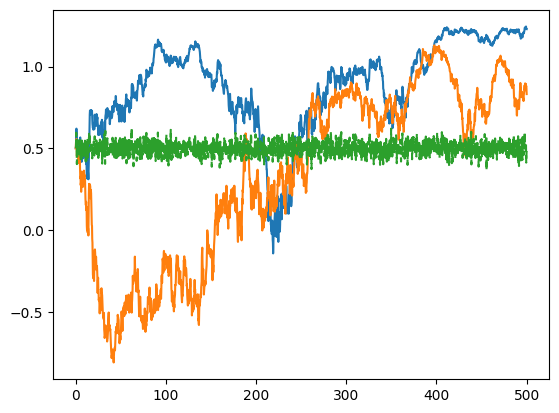

In [2]:

# Define the ODE
def f(t, x):
    return -(1 / 10)**2 * jnp.sin(x)*jnp.cos(x)**3

def g(t, x):
    return 1/10 * jnp.cos(x)**2

def f_true(Wt,t, x0):
    return jnp.arctan(1/10 * Wt + jnp.tan(x0))

# Define the initial condition
x0 = jnp.ones((1,))*0.5

# Define the time points to evaluate
t = jnp.linspace(0., 500., 2000)

# Solve the ODE
key = jax.random.PRNGKey(2)
x,W  = sdeint(key, f, g, x0, t, method="euler_maruyama", noise_type="diagonal", return_brownian=True)
#with jax.disable_jit():
x2, W2= sdeint(key, f, g, x0, t, method="sri2", noise_type="diagonal", return_brownian=True)
y = f_true(W, t, x0)


# Plot the solution

plt.plot(t, x)
plt.plot(t, x2)
plt.plot(t, f_true(W , t, x0), "--")